# Kernel-based MC Neutron Transport


In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

from nuclear_data import *
from mf6 import *
from mf4 import *
from transport import *
from transport_kernel import *
from decay_activity import *
from notebook_helpers import *

#PROJECT_ROOT = Path.cwd()
CURRENT_ROOT = Path.cwd()
PROJECT_ROOT = Path("/Users/mathewoaks/Desktop/Activation_Code/neutron_activation/Activation_Data/nuclear_data_npz")

#print("Project folder:", PROJECT_ROOT)

## 0. Folders and Directories

In [2]:
# ============================================================
# Project folders
# ============================================================
# This notebook expects this repo layout:
#
# event-driven-monte-carlo-neutron-transport/
#     nuclear_data.py
#     transport.py
#     mf4.py
#     mf6.py
#     decay_activity.py
#     notebook_helpers.py
#     materials/
#         Steel.py
#         Concrete.py
#     data/
#         neutron_npz/
#         decay_npz/
#     outputs/
#
# The data folder is intentionally not included on GitHub.
# Users must provide their own processed NPZ nuclear data.
# ============================================================

#DATA_DIR = PROJECT_ROOT / "data"
#XS_DIR = DATA_DIR / "neutron_npz"
#DECAY_DIR = DATA_DIR / "decay_npz"
XS_DIR = PROJECT_ROOT / "neutron_npz"
DECAY_DIR = PROJECT_ROOT / "decay_npz"

KERNEL_DIR = Path("kernels")
KERNEL_DIR.mkdir(exist_ok=True)
 
KERNEL_NPZ_PATH = KERNEL_DIR / "material_transport_kernel_v1.npz"

MATERIALS_DIR = CURRENT_ROOT / "materials"
OUTPUT_DIR = CURRENT_ROOT / "outputs"

OUTPUT_DIR.mkdir(exist_ok=True)

print("XS_DIR:", XS_DIR)
print("DECAY_DIR:", DECAY_DIR)
print("MATERIALS_DIR:", MATERIALS_DIR)
print("OUTPUT_DIR:", OUTPUT_DIR)

XS_DIR: /Users/mathewoaks/Desktop/Activation_Code/neutron_activation/Activation_Data/nuclear_data_npz/neutron_npz
DECAY_DIR: /Users/mathewoaks/Desktop/Activation_Code/neutron_activation/Activation_Data/nuclear_data_npz/decay_npz
MATERIALS_DIR: /Users/mathewoaks/Desktop/Kernel_Based_MC_NT/materials
OUTPUT_DIR: /Users/mathewoaks/Desktop/Kernel_Based_MC_NT/outputs


In [ ]:
if not XS_DIR.exists():
    raise FileNotFoundError(
        f"Missing neutron data folder: {XS_DIR}\n"
        "Create data/neutron_npz/ and place your processed neutron NPZ files there."
    )

if not DECAY_DIR.exists():
    raise FileNotFoundError(
        f"Missing decay data folder: {DECAY_DIR}\n"
        "Create data/decay_npz/ and place your processed decay NPZ files there."
    )

if not MATERIAL_FILE.exists():
    raise FileNotFoundError(
        f"Missing material file: {MATERIAL_FILE}\n"
        "Place material files in materials/ or in the repo root."
    )

## 1. User controls

In [ ]:
MATERIAL_NAME = "Steel"          # Change to "Concrete" or another material file.

# Prefer materials/Steel.py, but fall back to Steel.py in the repo root.
MATERIAL_FILE = MATERIALS_DIR / f"{MATERIAL_NAME}.py"
if not MATERIAL_FILE.exists():
    MATERIAL_FILE = PROJECT_ROOT / f"{MATERIAL_NAME}.py"

In [ ]:
RANDOM_SEED = None                  # Use None to avoid forcing reproducibility.
RESET_CACHE_BEFORE_RUN = True

In [ ]:
# Transport settings.
TRANSPORT_MODE = "many"        # "single" or "many".
INITIAL_ENERGY_EV = 14.0e6       # 14 MeV source neutron.
BOX_SIZE_M = 5.0
MAX_EVENTS = 1e4                 # Single-source event cap.
MAX_NEUTRONS = 1e3                # Single-source neutron-object cap.
N_SOURCE_NEUTRONS = 1e4          # Used only when TRANSPORT_MODE = "many".
MAX_EVENTS_PER_SOURCE = 1e4      # Many-source event cap per source neutron.
MAX_NEUTRONS_PER_SOURCE = 1e3     # Many-source neutron-object cap per source neutron.
MAX_TRAJECTORY_PATHS = 80        # Plot cap used only in many-source mode.

# Transport kernel settings.
USE_TRANSPORT_KERNEL = True
KERNEL_E_MIN_EV = 1.0e-5
KERNEL_E_MAX_EV = 2.0e7
KERNEL_BINS_PER_DECADE = 100

LOAD_KERNEL_IF_EXISTS = True
BUILD_MF4_ELASTIC_KERNEL = True
MF4_MU_GRID_COUNT = 801

In [ ]:
# Starting neutron state.
START_X = 0.0
START_Y = 0.0
START_DIRECTION = None           # Used only in single-source mode; None samples a random 2D direction.

In [ ]:
# Activity plotting controls.
ACTIVITY_POINTS_PER_DECADE = 100
ACTIVITY_MIN_LINEAR_POINTS = 400
ACTIVITY_HALF_LIVES_TO_SHOW = 8.0
MIN_ACTIVITY_HALF_LIFE_S = 1.0e-12

In [ ]:
print("MATERIAL_NAME:", MATERIAL_NAME)
print("MATERIAL_FILE:", MATERIAL_FILE)
print("TRANSPORT_MODE:", TRANSPORT_MODE)
print("INITIAL_ENERGY_EV:", INITIAL_ENERGY_EV)
print("BOX_SIZE_M:", BOX_SIZE_M)
if str(TRANSPORT_MODE).strip().lower() == "many":
    print("N_SOURCE_NEUTRONS:", N_SOURCE_NEUTRONS)

## 2. Load material

In [4]:
material, material_df = load_material_summary(
    material_file=str(MATERIAL_FILE),
    xs_dir=str(XS_DIR),
)

display(material_df)

Material: Steel (generic carbon steel, Z < 34)
Density: 7.85 g/cm^3
Loaded isotope count: 17
Missing XS files: []


,isotope,element,number_density_m3,mass_fraction
14,Fe-56,Fe,7.592280e+28,8.993727e-01
13,Fe-54,Fe,5.015636e+27,5.729269e-02
15,Fe-57,Fe,1.722627e+27,2.077044e-02
0,C-12,C,1.013306e+27,2.572180e-03
10,Mn-55,Mn,8.853094e+26,1.030000e-02
2,Si-28,Si,6.228661e+26,3.689200e-03
16,Fe-58,Fe,2.252975e+26,2.764164e-03
11,Cu-63,Cu,1.037773e+26,1.383000e-03
6,S-32,S,7.016467e+25,4.749500e-04
5,P-31,P,6.099846e+25,4.000000e-04


## 3. Inspect reaction probabilities at the initial energy

In [5]:
reaction_preview_df, open_reactions, Sigma_total = reaction_preview_dataframe(
    material=material,
    energy_eV=INITIAL_ENERGY_EV,
    max_rows=40,
)

display(reaction_preview_df)

Total Sigma at initial energy = 21.958411928336353 1/m
Mean free path = 0.045540633961308676 m
Mean free path = 4.554063396130867 cm


,target_isotope,mt,reaction,sigma_barns,Sigma_1_per_m,probability
0,Fe-56,2,elastic scattering,1.177700,8.941429,0.407198
1,Fe-56,91,"(n,nc) continuum inelastic",0.640566,4.863360,0.221480
2,Fe-56,16,"(n,2n)",0.415721,3.156270,0.143739
3,Fe-56,103,"(n,p)",0.116309,0.883051,0.040215
4,Fe-54,2,elastic scattering,1.174305,0.588989,0.026823
5,Fe-56,51,"(n,n1) inelastic to 1st excited state",0.072684,0.551835,0.025131
6,Fe-56,28,"(n,np)",0.050286,0.381785,0.017387
7,Fe-56,107,"(n,alpha)",0.041513,0.315178,0.014353
8,Fe-54,28,"(n,np)",0.553514,0.277622,0.012643
9,Fe-57,2,elastic scattering,1.175880,0.202560,0.009225


In [6]:
# Build precomputed transport kernel

if USE_TRANSPORT_KERNEL:
    if LOAD_KERNEL_IF_EXISTS and KERNEL_NPZ_PATH.exists():
        kernel = load_material_transport_kernel_npz(
            path=KERNEL_NPZ_PATH,
            material=material,
        )
    else:
        kernel = build_material_transport_kernel(
            material=material,
            E_min_eV=KERNEL_E_MIN_EV,
            E_max_eV=KERNEL_E_MAX_EV,
            bins_per_decade=KERNEL_BINS_PER_DECADE,
            print_progress=True,
            build_mf4_elastic=BUILD_MF4_ELASTIC_KERNEL,
            mf4_mu_grid_count=MF4_MU_GRID_COUNT,
        )

        save_material_transport_kernel_npz(
            kernel=kernel,
            path=KERNEL_NPZ_PATH,
        )

    kernel_summary(kernel)

else:
    kernel = None
    print("Transport kernel disabled. Using old runtime reaction-list path.")

Loaded flat transport kernel: kernels/material_transport_kernel_v1.npz
Kernel kind: material_reaction_kernel_v1
Material: Steel (generic carbon steel, Z < 34)
Energy range: 1e-05 to 20000000.0 eV
Bins per decade: 100
Storage: flat arrays
Total bins: 1231
Bins with open reactions: 1231
Total channels: 96319
Multiplicity kernel channels: 96319
Multiplicity MF6-yield channels: 31617
Multiplicity stochastic-integer channels: 451
Residual-product kernel channels: 96319
Residual MF10 branch-CDF channels: 1582

First nonzero bins:
bin     0 | E = 1.011571e-05 eV | Sigma = 1.217565e+03 1/m | channels = 40
bin     1 | E = 1.035116e-05 eV | Sigma = 1.204714e+03 1/m | channels = 40
bin     2 | E = 1.059209e-05 eV | Sigma = 1.192010e+03 1/m | channels = 40
bin     3 | E = 1.083863e-05 eV | Sigma = 1.179451e+03 1/m | channels = 40
bin     4 | E = 1.109091e-05 eV | Sigma = 1.167036e+03 1/m | channels = 40
bin     5 | E = 1.134906e-05 eV | Sigma = 1.154763e+03 1/m | channels = 40
bin     6 | E = 1.16

## 4. Run event-driven kernel-based transport

In [8]:
transport_mode = str(TRANSPORT_MODE).strip().lower()
if transport_mode not in {"single", "many"}:
    raise ValueError("TRANSPORT_MODE must be \"single\" or \"many\".")

if transport_mode == "single":
    neutrons, hist_df, execution_time = run_single_source_transport(
        material=material,
        initial_energy_eV=INITIAL_ENERGY_EV,
        box_size_m=BOX_SIZE_M,
        start_x=START_X,
        start_y=START_Y,
        start_direction=START_DIRECTION,
        max_events=MAX_EVENTS,
        max_neutrons=MAX_NEUTRONS,
        random_seed=RANDOM_SEED,
        reset_cache=RESET_CACHE_BEFORE_RUN,
        kernel=kernel,
    )
else:
    neutrons, hist_df, execution_time = run_many_source_transport(
        material=material,
        n_source_neutrons=N_SOURCE_NEUTRONS,
        initial_energy_eV=INITIAL_ENERGY_EV,
        box_size_m=BOX_SIZE_M,
        start_x=START_X,
        start_y=START_Y,
        max_events_per_source=MAX_EVENTS_PER_SOURCE,
        max_neutrons_per_source=MAX_NEUTRONS_PER_SOURCE,
        random_seed=RANDOM_SEED,
        reset_cache=RESET_CACHE_BEFORE_RUN,
        kernel=kernel,
    )

display(hist_df)

Source neutrons launched: 10000.0
Total neutron objects including secondaries: 12853
Alive at end: 0
Source histories represented: 10000
MC transport took 184.882368 seconds to complete.


,neutron_id,generation,parent_id,t,x,y,energy_eV,dir_x,dir_y,event,...,n_out_random_number,n_out_mt_count,n_out_mf6_total_yield,n_out_mf6_product_count,elastic_has_mf4_kernel,mf6_has_kernel,mf6_product_count,mf6_total_neutron_product_count,mf6_missing_product_count,num_secondaries_created
0,0,0,NaN,0.000000e+00,0.000000,0.000000,1.400000e+07,0.977429,0.211264,start,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,0,0,NaN,3.303140e-10,0.016709,0.003612,1.115708e+07,0.407961,0.912999,scatter-like,...,NaN,1.0,1.0,1.0,False,True,1.0,1.0,0.0,0.0
2,0,0,NaN,1.419685e-09,0.037241,0.049562,1.985652e+06,-0.875636,0.482972,scatter-like,...,NaN,1.0,1.0,1.0,False,True,1.0,1.0,0.0,0.0
3,0,0,NaN,1.623993e-09,0.033755,0.051486,1.983518e+06,-0.731663,0.681667,scatter-like,...,NaN,1.0,0.0,0.0,True,False,NaN,NaN,NaN,0.0
4,0,0,NaN,1.707591e-09,0.032563,0.052596,1.851751e+06,0.936243,-0.351352,scatter-like,...,NaN,1.0,0.0,0.0,True,False,NaN,NaN,NaN,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2491100,12852,0,NaN,7.320283e-05,0.353849,1.080745,3.225516e-01,0.503093,-0.864232,scatter-like,...,NaN,1.0,0.0,0.0,True,False,NaN,NaN,NaN,0.0
2491101,12852,0,NaN,7.485615e-05,0.360383,1.069521,3.198361e-01,-0.174352,-0.984683,scatter-like,...,NaN,1.0,0.0,0.0,True,False,NaN,NaN,NaN,0.0
2491102,12852,0,NaN,7.573261e-05,0.359188,1.062770,3.172851e-01,0.486066,-0.873922,scatter-like,...,NaN,1.0,0.0,0.0,True,False,NaN,NaN,NaN,0.0
2491103,12852,0,NaN,7.610457e-05,0.360596,1.060238,2.981603e-01,0.227336,0.973816,scatter-like,...,NaN,1.0,0.0,0.0,True,False,NaN,NaN,NaN,0.0


In [9]:
if "reaction_sampling_source" in hist_df.columns:
    display(hist_df["reaction_sampling_source"].value_counts(dropna=False))
else:
    print("No reaction_sampling_source column found.")
    print("This usually means Step 2 has not been added to transport.py yet.")

reaction_sampling_source
precomputed-flat-kernel-cdf    2475371
NaN                              15734
Name: count, dtype: int64

## 5. Transport diagnostics

Event counts:


event
scatter-like              2459767
start                       12853
absorbed                    12751
neutron multiplication       2853
created secondary            2853
escaped                        28
Name: count, dtype: int64

Target isotope counts:


target_isotope
Fe-56    2046170
Fe-54     191889
Mn-55     109698
Fe-57      70476
C-12       26435
NaN        15734
Fe-58      10511
Si-28      10096
Cu-63       4913
Cu-65       2022
S-32        1057
P-31         963
Si-29        478
Si-30        328
C-13         293
S-34          32
S-33          10
Name: count, dtype: int64

MT counts:


...

Events per source neutron:


,source_id,history_rows
count,10000.00000,10000.000000
mean,4999.50000,249.110500
std,2886.89568,183.802114
min,0.00000,2.000000
25%,2499.75000,89.000000
50%,4999.50000,254.000000
75%,7499.25000,361.000000
max,9999.00000,1342.000000


,source_id,history_rows
0,0,110
1,1,4
2,2,283
3,3,348
4,4,267
5,5,336
6,6,2
7,7,412
8,8,637
9,9,464


Cache summary:
Number of cached energy bins: 0
Total cache hits: 0
Total history rows: 2491105
Total neutron IDs: 12853

Event counts:
event
scatter-like              2459767
start                       12853
absorbed                    12751
neutron multiplication       2853
created secondary            2853
escaped                        28
Name: count, dtype: int64

Number of multiplication events: 2853
Number of created secondary rows: 2853
Expected secondaries: 2853
Actual created secondary rows: 2853
Events are monotonic in time? True


,neutron_id,generation,parent_id,t,x,y,energy_eV,dir_x,dir_y,event,...,n_out_random_number,n_out_mt_count,n_out_mf6_total_yield,n_out_mf6_product_count,elastic_has_mf4_kernel,mf6_has_kernel,mf6_product_count,mf6_total_neutron_product_count,mf6_missing_product_count,num_secondaries_created
594611,2971,0,NaN,1.040114e-13,0.000002,0.000005,1.394082e+07,-0.130994,0.991383,scatter-like,...,NaN,1.0,0.0,0.0,True,False,NaN,NaN,NaN,0.0
812032,4113,0,NaN,1.222442e-13,0.000003,-0.000006,1.400000e+07,0.470876,-0.882199,absorbed,...,NaN,0.0,0.0,0.0,False,False,NaN,NaN,NaN,0.0
1867697,9605,0,NaN,1.253565e-13,-0.000001,0.000006,3.431108e+06,0.654744,-0.755850,scatter-like,...,NaN,1.0,1.0,1.0,False,True,1.0,1.0,0.0,0.0
1736296,8914,0,NaN,2.748732e-13,0.000010,-0.000010,6.526312e+05,-0.319971,0.947427,neutron multiplication,...,NaN,2.0,2.0,1.0,False,True,1.0,1.0,0.0,1.0
803363,4076,0,NaN,4.001763e-13,-0.000020,-0.000005,1.400000e+07,-0.969962,-0.243256,absorbed,...,NaN,0.0,0.0,0.0,False,False,NaN,NaN,NaN,0.0
247047,1204,0,NaN,4.657595e-13,0.000022,-0.000009,6.633197e+05,-0.367844,0.929888,neutron multiplication,...,NaN,2.0,2.0,1.0,False,True,1.0,1.0,0.0,1.0
2261958,11664,0,NaN,4.834425e-13,0.000005,-0.000025,7.792592e+05,0.802871,0.596153,scatter-like,...,NaN,1.0,1.0,1.0,False,True,1.0,1.0,0.0,0.0
1533891,7853,0,NaN,5.630401e-13,-0.000026,-0.000013,5.107782e+06,0.999963,0.008621,scatter-like,...,NaN,1.0,1.0,1.0,False,True,1.0,1.0,0.0,0.0
1490983,7629,0,NaN,6.245385e-13,-0.000018,0.000027,2.742127e+05,-0.994303,-0.106593,neutron multiplication,...,NaN,2.0,2.0,1.0,False,True,1.0,1.0,0.0,1.0
2151215,11106,0,NaN,8.450243e-13,0.000012,-0.000042,3.570769e+06,0.847170,0.531322,scatter-like,...,NaN,1.0,1.0,1.0,False,True,1.0,1.0,0.0,0.0


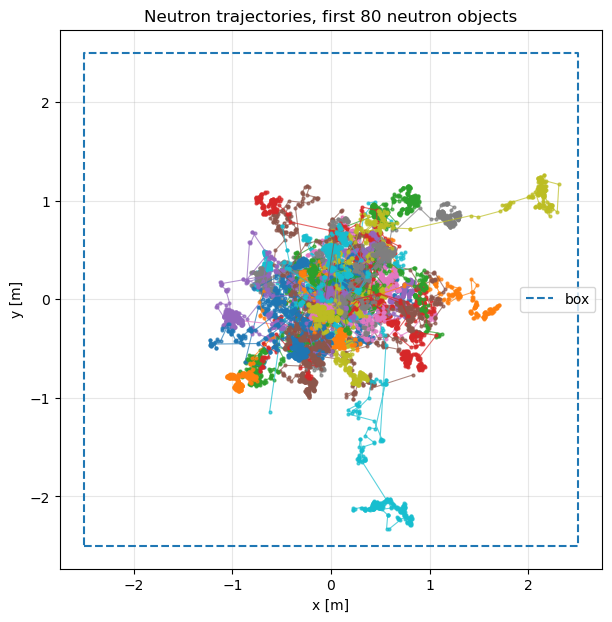

(<Figure size 700x700 with 1 Axes>,
 <Axes: title={'center': 'Neutron trajectories, first 80 neutron objects'}, xlabel='x [m]', ylabel='y [m]'>)

In [10]:
include_source_summary = transport_mode == "many"
trajectory_max_paths = None if transport_mode == "single" else MAX_TRAJECTORY_PATHS

time_ordered_events = show_transport_diagnostics(
    hist_df=hist_df,
    material=material,
    include_source_summary=include_source_summary,
)

In [ ]:
plot_neutron_trajectories(
    neutrons=neutrons,
    box_size_m=BOX_SIZE_M,
    max_paths=trajectory_max_paths,
    save_name="neutron_traj.png",
    show_labels=(transport_mode == "single"),
)

## 6. Residual products and activation inventory

In [11]:
products_df = summarize_residual_products(hist_df)
display(products_df)

activation_df = activation_product_dataframe(hist_df)
display(activation_df)

inventory_summary = activation_inventory_summary(hist_df)
display(inventory_summary)

reaction_inventory = activation_inventory_by_reaction(hist_df)
display(reaction_inventory)

Residual product counts:
residual_product
Fe-56    16406
Fe-57    15521
Fe-55     3527
Mn-56     2398
Mn-55     1553
Fe-58      605
Fe-54      565
Cr-53      319
Mn-54      275
Mn-53      240
Cu-64       58
C-12        53
Si-28       48
Cr-51       43
Fe-59       22
Cu-63       20
Al-28       16
Si-31       15
Cr-54       15
Si-29       12
Mg-25       10
Be-9         9
Cu-65        7
He-4         6
Mn-57        6
Cr-55        5
Al-27        5
Cu-66        5
Cr-52        3
P-31         3
Ni-62        3
S-32         2
Cu-62        2
V-52         1
C-13         1
P-32         1
Si-30        1
Mn-58        1
Fe-53        1
Be-8         1
Name: count, dtype: int64

Products by MT:
mt     reaction_name               residual_product
4.0    total inelastic scattering  Fe-57               4186
16.0   (n,2n)                      C-12                   1
                                   Cu-62                  2
                                   Cu-64                  2
                       

,neutron_id,generation,parent_id,t,x,y,target_isotope,mt,reaction_name,residual_product,residual_product_Z,residual_product_A,product_note,incoming_energy_eV,outgoing_energy_eV,energy_update_source
1,0,0,NaN,3.303140e-10,0.016709,0.003612,Fe-54,52.0,"(n,n2) inelastic to 2nd excited state",Fe-54,26.0,54.0,"inelastic scattering, residual nucleus is same...",1.400000e+07,1.115708e+07,kernel-MF6-LAW2-two-body
2,0,0,NaN,1.419685e-09,0.037241,0.049562,Fe-56,91.0,"(n,nc) continuum inelastic",Fe-56,26.0,56.0,"inelastic scattering, residual nucleus is same...",1.115708e+07,1.985652e+06,kernel-MF6-LAW1
5,0,0,NaN,2.324598e-09,0.043436,0.048515,Fe-56,51.0,"(n,n1) inelastic to 1st excited state",Fe-56,26.0,56.0,"inelastic scattering, residual nucleus is same...",1.851751e+06,9.842482e+05,kernel-MF6-LAW2-two-body
6,0,0,NaN,5.887246e-09,0.085445,0.073520,Fe-57,53.0,"(n,n3) inelastic to 3rd excited state",Fe-57,26.0,57.0,"inelastic scattering, residual nucleus is same...",9.842482e+05,5.444328e+05,kernel-MF6-LAW2-two-body
80,0,0,NaN,6.193509e-07,0.589909,0.100446,Fe-57,4.0,total inelastic scattering,Fe-57,26.0,57.0,"inelastic scattering, residual nucleus is same...",2.424552e+04,2.424552e+04,unchanged-no-MF6
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2490604,12851,1,12850.0,4.385557e-08,-0.328404,0.135771,Fe-56,51.0,"(n,n1) inelastic to 1st excited state",Fe-56,26.0,56.0,"inelastic scattering, residual nucleus is same...",1.128608e+06,2.601721e+05,kernel-MF6-LAW2-two-body
2490690,12851,1,12850.0,1.130875e-06,0.217817,0.246609,Fe-54,102.0,"(n,gamma)",Fe-55,26.0,55.0,residual product,1.122973e+04,NaN,absorbed-no-outgoing-neutron
2490693,12852,0,NaN,2.419214e-09,-0.020332,-0.123162,Fe-54,91.0,"(n,nc) continuum inelastic",Fe-54,26.0,54.0,"inelastic scattering, residual nucleus is same...",1.399127e+07,5.691919e+06,kernel-MF6-LAW1
2490696,12852,0,NaN,7.653354e-09,0.086235,0.002997,Fe-56,91.0,"(n,nc) continuum inelastic",Fe-56,26.0,56.0,"inelastic scattering, residual nucleus is same...",5.670237e+06,4.966206e+05,kernel-MF6-LAW1


,neutron_id,generation,parent_id,t,x,y,target_isotope,mt,reaction_name,residual_product,residual_product_Z,residual_product_A,incoming_energy_eV,outgoing_energy_eV,energy_update_source
109,0,0,NaN,9.766387e-07,0.634901,0.233315,Fe-57,102.0,"(n,gamma)",Fe-58,26.0,58.0,6.631727e+03,NaN,absorbed-no-outgoing-neutron
113,1,0,NaN,5.864038e-10,0.001189,0.029459,Fe-56,103.0,"(n,p)",Mn-56,25.0,56.0,1.395033e+07,NaN,absorbed-no-outgoing-neutron
396,2,0,NaN,1.320667e-05,0.331337,-0.076577,Fe-56,102.0,"(n,gamma)",Fe-57,26.0,57.0,1.215242e+01,NaN,absorbed-no-outgoing-neutron
398,3,0,NaN,8.351823e-10,-0.017934,-0.039327,Fe-56,16.0,"(n,2n)",Fe-55,26.0,55.0,1.400000e+07,500111.826203,kernel-MF6-LAW1
621,3,0,NaN,1.320435e-05,0.576336,-0.085102,Fe-56,102.0,"(n,gamma)",Fe-57,26.0,57.0,1.313616e+01,NaN,absorbed-no-outgoing-neutron
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2490391,12849,1,12848.0,7.531803e-06,0.418462,0.675000,Fe-56,102.0,"(n,gamma)",Fe-57,26.0,57.0,5.970804e+01,NaN,absorbed-no-outgoing-neutron
2490393,12850,0,NaN,2.180550e-09,-0.029177,0.109013,Fe-56,16.0,"(n,2n)",Fe-55,26.0,55.0,1.400000e+07,360066.524391,kernel-MF6-LAW1
2490598,12850,0,NaN,5.426980e-06,-0.376811,0.714795,Fe-56,102.0,"(n,gamma)",Fe-57,26.0,57.0,5.455901e+01,NaN,absorbed-no-outgoing-neutron
2490690,12851,1,12850.0,1.130875e-06,0.217817,0.246609,Fe-54,102.0,"(n,gamma)",Fe-55,26.0,55.0,1.122973e+04,NaN,absorbed-no-outgoing-neutron


,residual_product,count
15,Fe-57,8136
13,Fe-55,3527
23,Mn-56,2398
16,Fe-58,543
22,Mn-55,333
7,Cr-53,319
21,Mn-54,275
20,Mn-53,240
14,Fe-56,153
11,Cu-64,58


,mt,reaction_name,residual_product,count
23,102.0,"(n,gamma)",Fe-57,8115
3,16.0,"(n,2n)",Fe-55,2615
26,102.0,"(n,gamma)",Mn-56,1547
22,102.0,"(n,gamma)",Fe-55,912
32,103.0,"(n,p)",Mn-56,849
24,102.0,"(n,gamma)",Fe-58,543
42,107.0,"(n,alpha)",Cr-53,318
15,28.0,"(n,np)",Mn-55,303
14,28.0,"(n,np)",Mn-53,234
31,103.0,"(n,p)",Mn-54,220


## 7. Decay status

In [12]:
activation_df_with_decay = add_decay_status_to_activation_products(
    activation_df=activation_df,
    decay_dir=DECAY_DIR,
)

display(activation_df_with_decay)

decay_status_summary = summarize_activation_with_decay_status(
    hist_df=hist_df,
    decay_dir=DECAY_DIR,
)

display(decay_status_summary)

,neutron_id,generation,parent_id,t,x,y,target_isotope,mt,reaction_name,residual_product,...,decay_filename,has_decay_file,half_life_s,is_stable,is_radioactive,decay_daughters,branching_ratios,qvalues_eV,decay_energy_eV,decay_note
109,0,0,NaN,9.766387e-07,0.634901,0.233315,Fe-57,102.0,"(n,gamma)",Fe-58,...,dec-026_Fe_58.npz,True,inf,True,False,[],[],[],0.000,stable isotope
113,1,0,NaN,5.864038e-10,0.001189,0.029459,Fe-56,103.0,"(n,p)",Mn-56,...,dec-025_Mn_56.npz,True,9284.04,False,True,[Fe-56],[1.0],[3695500.0],2522640.300,radioactive isotope
396,2,0,NaN,1.320667e-05,0.331337,-0.076577,Fe-56,102.0,"(n,gamma)",Fe-57,...,dec-026_Fe_57.npz,True,inf,True,False,[],[],[],0.000,stable isotope
398,3,0,NaN,8.351823e-10,-0.017934,-0.039327,Fe-56,16.0,"(n,2n)",Fe-55,...,dec-026_Fe_55.npz,True,86594050.00,False,True,[Mn-55],[1.0],[231210.0],5842.102,radioactive isotope
621,3,0,NaN,1.320435e-05,0.576336,-0.085102,Fe-56,102.0,"(n,gamma)",Fe-57,...,dec-026_Fe_57.npz,True,inf,True,False,[],[],[],0.000,stable isotope
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2490391,12849,1,12848.0,7.531803e-06,0.418462,0.675000,Fe-56,102.0,"(n,gamma)",Fe-57,...,dec-026_Fe_57.npz,True,inf,True,False,[],[],[],0.000,stable isotope
2490393,12850,0,NaN,2.180550e-09,-0.029177,0.109013,Fe-56,16.0,"(n,2n)",Fe-55,...,dec-026_Fe_55.npz,True,86594050.00,False,True,[Mn-55],[1.0],[231210.0],5842.102,radioactive isotope
2490598,12850,0,NaN,5.426980e-06,-0.376811,0.714795,Fe-56,102.0,"(n,gamma)",Fe-57,...,dec-026_Fe_57.npz,True,inf,True,False,[],[],[],0.000,stable isotope
2490690,12851,1,12850.0,1.130875e-06,0.217817,0.246609,Fe-54,102.0,"(n,gamma)",Fe-55,...,dec-026_Fe_55.npz,True,86594050.00,False,True,[Mn-55],[1.0],[231210.0],5842.102,radioactive isotope


,residual_product,decay_filename,has_decay_file,is_stable,is_radioactive,half_life_s,decay_note,count,decay_daughters,branching_ratios,qvalues_eV,decay_energy_eV
15,Fe-57,dec-026_Fe_57.npz,True,True,False,inf,stable isotope,8136,[],[],[],0.000000e+00
13,Fe-55,dec-026_Fe_55.npz,True,False,True,8.659405e+07,radioactive isotope,3527,['Mn-55'],[1.0],[231210.0],5.842102e+03
23,Mn-56,dec-025_Mn_56.npz,True,False,True,9.284040e+03,radioactive isotope,2398,['Fe-56'],[1.0],[3695500.0],2.522640e+06
16,Fe-58,dec-026_Fe_58.npz,True,True,False,inf,stable isotope,543,[],[],[],0.000000e+00
22,Mn-55,dec-025_Mn_55.npz,True,True,False,inf,stable isotope,333,[],[],[],0.000000e+00
7,Cr-53,dec-024_Cr_53.npz,True,True,False,inf,stable isotope,319,[],[],[],0.000000e+00
21,Mn-54,dec-025_Mn_54.npz,True,False,True,2.696112e+07,radioactive isotope,275,['Cr-54'],[1.0],[1377200.0],8.401730e+05
20,Mn-53,dec-025_Mn_53.npz,True,False,True,1.167630e+14,radioactive isotope,240,['Cr-53'],[1.0],[596800.0],5.387326e+03
14,Fe-56,dec-026_Fe_56.npz,True,True,False,inf,stable isotope,153,[],[],[],0.000000e+00
11,Cu-64,dec-029_Cu_64.npz,True,False,True,4.572360e+04,radioactive isotope,58,"['Ni-64', 'Zn-64']","[0.6150000095367432, 0.38499999046325684]","[1675030.0, 579400.0]",3.118787e+05


## 8. Direct activity and daughter-chain activity

In [ ]:
time_grid_s, direct_activity_df, chain_activity_df, production_events, activation_df_with_decay = compute_activity_outputs(
    hist_df=hist_df,
    decay_dir=DECAY_DIR,
    points_per_decade=ACTIVITY_POINTS_PER_DECADE,
    min_linear_points=ACTIVITY_MIN_LINEAR_POINTS,
    half_lives_to_show=ACTIVITY_HALF_LIVES_TO_SHOW,
    max_chain_generations=20,
    min_activity_half_life_s=MIN_ACTIVITY_HALF_LIFE_S,
)

In [ ]:
plot_direct_vs_chain_activity_auto(direct_activity_df, chain_activity_df)

plot_total_activity_auto(
    chain_activity_df,
    y_col="total_Ci",
    ylabel="total activity [Ci]",
    save_name="total_activity.png",
)

plot_isotope_activities_auto(chain_activity_df, unit="Bq", save_name="isotope_activities.png")

## 9. Save outputs

In [15]:
hist_path = OUTPUT_DIR / "transport_history.csv"
products_path = OUTPUT_DIR / "residual_products.csv"
activation_path = OUTPUT_DIR / "activation_products_with_decay.csv"
activity_path = OUTPUT_DIR / "activity_chain.csv"

hist_df.to_csv(hist_path, index=False)
products_df.to_csv(products_path, index=False)
activation_df_with_decay.to_csv(activation_path, index=False)
chain_activity_df.to_csv(activity_path, index=False)

print("Saved:")
print(hist_path)
print(products_path)
print(activation_path)
print(activity_path)

Saved:
/Users/mathewoaks/Desktop/Kernel_Based_MC_NT/outputs/transport_history.csv
/Users/mathewoaks/Desktop/Kernel_Based_MC_NT/outputs/residual_products.csv
/Users/mathewoaks/Desktop/Kernel_Based_MC_NT/outputs/activation_products_with_decay.csv
/Users/mathewoaks/Desktop/Kernel_Based_MC_NT/outputs/activity_chain.csv
